# Two-Photon Pulse

This example demonstrates how to optimize a CZ gate if the qubit state $|1\rangle$ is coupled to the Rydberg state $|r\rangle$ via an intermediate state $|e\rangle$. The example reproduces the nearly time-optimal gate from [Evered et al. (2023), Nature 622, 268-272 (2023)](https://doi.org/10.1038/s41586-023-06481-y).

In [1]:
# %pip install -q --progress-bar off rydopt # Uncomment for installation on Colab

import rydopt as ro
import numpy as np
import jax.numpy as jnp

First, we create the target gate.

In [2]:
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=450, decay=0)

We then implement the phase ansatz function from the publication.

In [ ]:
class EveredPhase(ro.pulses.PulseAnsatzFunction):
    def __init__(self, num_params: int = 3) -> None:
        if num_params != 3:
            raise ValueError("EveredPhase requires exactly 3 parameters")
        super().__init__(num_params)

    def __call__(
        self, t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray
    ) -> jnp.ndarray:
        del duration
        a, omega, phi0 = ansatz_params
        return a * jnp.cos(omega * t - phi0)


evered_phase = EveredPhase()

We use it and pre-defined constant ansatz functions to define a two-photon pulse ansatz. We first define the ansatz for the lower transition $|1\rangle \leftrightarrow |e\rangle$, then for the upper transition $|e\rangle \leftrightarrow |r\rangle$. We combine both ansatz objects in a `TwoPhotonPulseAnsatz`.

In [ ]:
lower = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.Const(),
    phase_ansatz=evered_phase,
    rabi_ansatz=ro.pulses.Const(),
)
upper = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.Const(),
    rabi_ansatz=ro.pulses.Const(),
)
pulse_ansatz = ro.pulses.TwoPhotonPulseAnsatz(
    lower_transition=lower,
    upper_transition=upper,
    decay=0,
)

We optimize the pulse parameters starting from 10 random parameter initializations. The initial values are chosen from a range specified by `min_initial_params` and `max_initial_params`. These are `ro.pulses.PulseParams(...)` containers with the min/max gate duration and parameters for the detuning/phase/rabi ansatz functions. Each parameter array is packed as `[*lower_transition_params, *upper_transition_params]`. The split positions are inferred from the ansatz objects of the lower transition.

We assume the detunings and Rabi frequencies as fixed, using the values from the publication, and tune the other parameters to optimize the gate fidelity. All values are provided in units of $2\pi \times 1 \text{ MHz}$.

In [ ]:
omega_l = 237
omega_u = 303
detuning_l = -7.8e3
detuning_u = -detuning_l - (omega_l**2 - omega_u**2) / (4 * detuning_l)

min_initial_params = ro.pulses.PulseParams(
    1.0,
    [detuning_l, detuning_u],
    [0.5, 3.0, -1.0],
    [omega_l, omega_u],
)
max_initial_params = ro.pulses.PulseParams(
    2.0,
    [detuning_l, detuning_u],
    [1.0, 6.0, -0.5],
    [omega_l, omega_u],
)
fixed_initial_params = ro.pulses.PulseParams(
    False,
    [True, True],
    [False, False, False],
    [True, True],
)

result = ro.optimization.multi_start_optimize(
    gate,
    pulse_ansatz,
    min_initial_params,
    max_initial_params,
    fixed_initial_params,
    num_steps=300,
    tol=1e-7,
    num_initializations=10,
    num_processes=1,
    return_history=False,
    return_all=False,
)

Started optimization using 1 process



proc00:   0%|                | 0/300 [00:00<?, ?it/s]


=== Optimization finished using multi-start Adam ===

Runtime: 23.237 seconds
Gates with infidelity below tol=1.0e-07: 8

Slowest gate:
> infidelity <= tol
> parameters = (1.6591487674115752, [-7800.          7798.85769231], [ 0.69705774  4.83123983 -0.70452884], [237. 303.])
> duration = 1.6591487674115752

Fastest gate:
> infidelity <= tol
> parameters = (1.6591309313899778, [-7800.          7798.85769231], [ 0.69700364  4.83164103 -0.70422615], [237. 303.])
> duration = 1.6591309313899778
> one-sided bootstrap error on duration: 1e-07


We plot the optimized effective two-photon pulse.

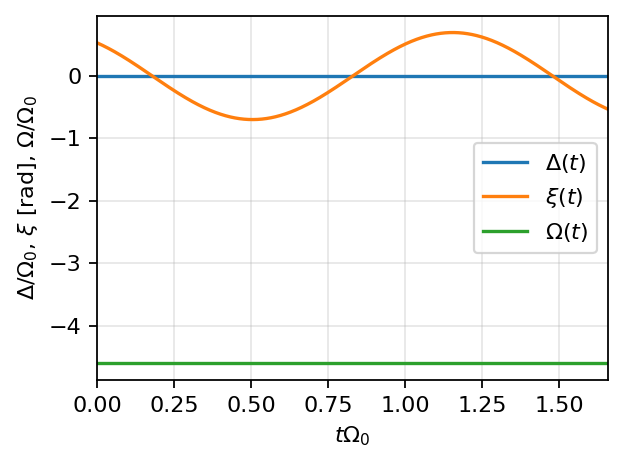

In [19]:
ro.characterization.plot_pulse(pulse_ansatz, result.params);

Finally, we compare the resulting gate duration against the result from the publication.

In [20]:
duration = result.params[0]
rabi_eff = abs(pulse_ansatz.evaluate_pulse_functions(0, result.params)[3].real)
print(f"Gate duration (Omega*T / 2pi): {duration * rabi_eff / (2 * np.pi):.3f}")
assert np.allclose(duration * rabi_eff / (2 * np.pi), 1.215, rtol=1e-3)

Gate duration (Omega*T / 2pi): 1.216


And calculate the infidelity resulting from the finite lifetime of the intermediate state.

In [ ]:
pulse_ansatz_with_decay = ro.pulses.TwoPhotonPulseAnsatz(
    lower_transition=lower,
    upper_transition=upper,
    decay=1 / (2 * np.pi * 110e-3),
)
infidelity = abs(
    1 - ro.simulation.average_gate_fidelity(gate, pulse_ansatz_with_decay, result.params)
)
print(f"Average gate infidelity due to intermediate state decay: {infidelity:.3%}")

Average gate infidelity due to intermediate state decay: 0.029%
